In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axisartist.axislines import AxesZero
from math import sqrt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",   # or 'sans-serif', or specific like 'cmr10'
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: for math fonts
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [31]:
def interpolate_colors(color1, color2, steps):
    """
    Linearly interpolate between two RGB colors.
    
    Args:
        color1 (str): Starting color in hex format (e.g., "#FF0000")
        color2 (str): Ending color in hex format (e.g., "#0000FF")
        steps (int): Number of color steps to generate (including start and end colors)
    
    Returns:
        list: List of hex color strings showing the interpolation from color1 to color2
    """
    # Remove '#' if present
    color1 = color1.lstrip('#')
    color2 = color2.lstrip('#')
    
    # Convert hex to RGB values
    r1, g1, b1 = tuple(int(color1[i:i+2], 16) for i in (0, 2, 4))
    r2, g2, b2 = tuple(int(color2[i:i+2], 16) for i in (0, 2, 4))
    
    # Generate interpolated colors
    result = []
    for i in range(steps):
        # Calculate the ratio for this step (0 at start, 1 at end)
        ratio = i / (steps - 1) if steps > 1 else 0
        
        # Linear interpolation for each RGB component
        r = int(r1 * (1 - ratio) + r2 * ratio)
        g = int(g1 * (1 - ratio) + g2 * ratio)
        b = int(b1 * (1 - ratio) + b2 * ratio)
        
        # Convert back to hex
        hex_color = "#{:02x}{:02x}{:02x}".format(r, g, b)
        result.append(hex_color)
    
    return result

In [50]:
beta_d_plus = 1
beta_d = 3
beta_k = 5
N = 15

assert N > 2

resolution = 100
beta_min, beta_max = 0, 6
beta_prime_min, beta_prime_max = 0, 6
beta_almost_max = 5.5
beta_prime_almost_max = 5.5

beta_prime_small_delta = (beta_prime_max - beta_prime_almost_max) / (N - 2)
beta_small_delta = (beta_max - beta_almost_max) / (N - 2)

beta = np.linspace(beta_min, beta_max, resolution)
beta_prime = np.linspace(beta_prime_min, beta_prime_max, resolution)
beta_grid, beta_prime_grid = np.meshgrid(beta_prime, beta)

# Custom colormap - add two new colors for above/below hyperbola
colors = ["#BBBBBB", "#FFE11F", "#AEDBAE"]

colors_interpolation = [interpolate_colors(c, "#FFFFFF", N) for c in colors]

x_offset = 0.1  # Horizontal position adjustment
y_offset = 0.1  # Vertical position adjustment
small_offset = 0.05  # Small offset for the second lower line

def hyperbola(x):
    A = (
        beta_d
        - sqrt(
            ((-4 + (beta_d - beta_d_plus) * (beta_d - beta_k)) * (beta_d - beta_k))
            / (beta_d - beta_d_plus)
        )
        + beta_k
    ) / 2.0
    C = (
        beta_d
        + beta_d_plus
        + sqrt(
            (beta_d - beta_d_plus)
            * (-4 + (beta_d - beta_d_plus) * (beta_d - beta_k))
            * (beta_d - beta_k)
        )
        / (beta_d - beta_k)
    ) / 2.0
    return 1 / (x - A) + C

In [51]:
# Generate hyperbola points
x_hyp = np.linspace(beta_d, beta_k, 100)
y_hyp = hyperbola(x_hyp)

x_upper_line = np.linspace(beta_prime_min, beta_prime_almost_max, 100)
y_upper_line = np.full_like(x_upper_line, beta_k)
x_upper_line_end = np.linspace(beta_prime_almost_max, beta_prime_max, 100)
y_upper_line_end = np.full_like(x_upper_line_end, beta_k)

x_lower_line = np.linspace(beta_prime_min, beta_d - 0.03, 100)
y_lower_line = np.full_like(x_lower_line, beta_d)

x_second_lower_line = np.linspace(beta_k + 0.03, beta_prime_almost_max, 100)
y_second_lower_line = np.full_like(x_second_lower_line, beta_d_plus)
x_second_lower_line_end = np.linspace(beta_prime_almost_max, beta_prime_max, 100)
y_second_lower_line_end = np.full_like(x_second_lower_line_end, beta_d_plus)

phases = np.zeros((resolution, resolution), dtype=int)

# Base regions as per your current version
phases[(beta_prime_grid <= beta_k) & (beta_d <= beta_prime_grid)] = 1
phases[
    (beta_prime_grid <= beta_d)
    & (beta_d_plus <= beta_prime_grid)
    & (beta_grid >= beta_k)
] = 1
phases[(beta_prime_grid <= beta_d_plus)] = 2
phases[(beta_prime_grid <= beta_d) & (beta_grid < beta_d)] = 2

for i in range(resolution):
    for j in range(resolution):
        b = beta[j]
        bp = beta_prime[i]

        if beta_d <= b <= beta_k:
            hyp_value = hyperbola(b)
            if bp <= hyp_value:
                phases[i, j] = 2
            elif bp > hyp_value:
                phases[i, j] = 1

phases[(beta_prime_grid > beta_k)] = 0

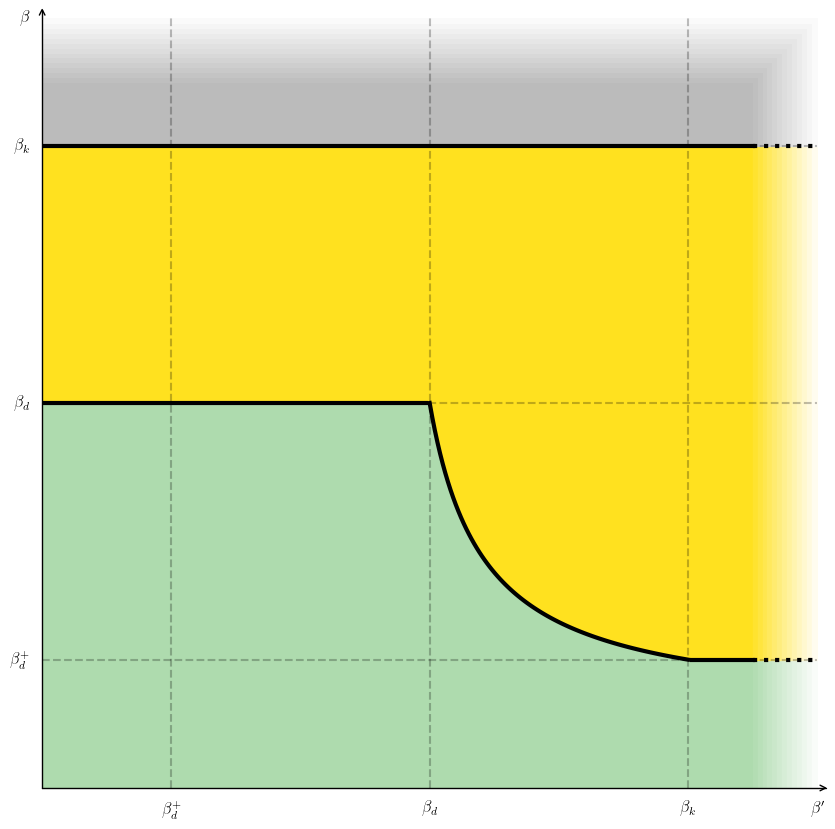

In [54]:
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(axes_class=AxesZero)

x_hyp_range = np.linspace(beta_d, beta_k, resolution)
y_hyp = hyperbola(x_hyp_range)

beta_range = np.linspace(beta_min, beta_almost_max, resolution)
beta_prime_range = np.linspace(beta_prime_min, beta_prime_almost_max, resolution)

# upper region (grey)
ax.fill_between(beta_prime_range, beta_k, beta_almost_max, color=colors[0])

# Region 2 (Green)
ax.fill_between(beta_prime_range, beta_min, beta_d_plus, color=colors[2])
mask = beta_prime_range < beta_d + small_offset
ax.fill_between(beta_prime_range, beta_d_plus, beta_d, color=colors[2], where=mask)
ax.fill_between(x_hyp_range, beta_min, y_hyp, color=colors[2])

# Region 1 (Gold): Area between hyperbola and beta_k horizontal line
ax.fill_between(x_hyp_range, y_hyp, beta_k, color=colors[1])
mask = beta_prime_range >= beta_k - small_offset
ax.fill_between(beta_prime_range, beta_d_plus, beta_k, color=colors[1], where=mask)
mask = beta_prime_range < beta_d + small_offset
ax.fill_between(beta_prime_range, beta_d, beta_k, color=colors[1], where=mask)

for i in range(1, N - 1):
    h_linspace = np.linspace(beta_prime_almost_max + (i-1) * beta_prime_small_delta, beta_prime_almost_max + i * beta_prime_small_delta, 30)
    # Region 2 (Green)
    ax.fill_between(
        h_linspace,
        beta_min,
        beta_d_plus,
        color=colors_interpolation[2][i]
    )

    # Region 1 (Gold)
    ax.fill_between(
        h_linspace,
        beta_d_plus,
        beta_k,
        color=colors_interpolation[1][i],
    )

    # Region 0 (Grey)
    ax.fill_between(
        h_linspace,
        beta_k,
        beta_almost_max + i * beta_small_delta,
        color=colors_interpolation[0][i],
    )

for i in range(1, N - 1):
    h_linspace = np.linspace(beta_prime_min, beta_prime_almost_max + (i-1) * beta_prime_small_delta, resolution)
    # region 0 (grey)
    ax.fill_between(
        h_linspace,
        beta_almost_max + (i-1) * beta_small_delta,
        beta_almost_max + i * beta_small_delta,
        color=colors_interpolation[0][i]
    )

ax.plot(x_hyp, y_hyp, "k-", linewidth=3)
ax.plot(x_upper_line, y_upper_line, "k-", linewidth=3)
ax.plot(x_lower_line, y_lower_line, "k-", linewidth=3)
ax.plot(x_second_lower_line, y_second_lower_line, "k-", linewidth=3)
ax.plot(x_upper_line_end, y_upper_line_end, "k:", linewidth=3)
ax.plot(x_second_lower_line_end, y_second_lower_line_end, "k:", linewidth=3)

# Add grid lines at key values
ax.axhline(y=beta_d_plus, color="black", linestyle="--", alpha=0.25)
ax.axhline(y=beta_d, color="black", linestyle="--", alpha=0.25)
ax.axhline(y=beta_k, color="black", linestyle="--", alpha=0.25)
ax.axvline(x=beta_d_plus, color="black", linestyle="--", alpha=0.25)
ax.axvline(x=beta_d, color="black", linestyle="--", alpha=0.25)
ax.axvline(x=beta_k, color="black", linestyle="--", alpha=0.25)

# Label the grid lines
ax.text(beta_min - x_offset, beta_d_plus, r"$\beta_d^+$", ha="right", va="center", fontsize=12)
ax.text(beta_min - x_offset, beta_d, r"$\beta_d$", ha="right", va="center", fontsize=12)
ax.text(beta_min - x_offset, beta_k, r"$\beta_k$", ha="right", va="center", fontsize=12)
ax.text(beta_d_plus, beta_min - y_offset, r"$\beta_d^+$", ha="center", va="top", fontsize=12)
ax.text(beta_d, beta_min - y_offset, r"$\beta_d$", ha="center", va="top", fontsize=12)
ax.text(beta_k, beta_min - y_offset, r"$\beta_k$", ha="center", va="top", fontsize=12)


# axes works
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-0.5, beta_max + 0.5)
ax.set_ylim(-0.5, beta_max + 0.5)

for direction in ["xzero", "yzero"]:
    ax.axis[direction].set_axisline_style("->")
    ax.axis[direction].set_visible(True)

for direction in ["left", "right", "bottom", "top"]:
    ax.axis[direction].set_visible(False)

ax.text(beta_prime_max, -y_offset, r"$\beta^\prime$", ha='center', va='top', fontsize=12)
ax.text(-x_offset, beta_max, r"$\beta$", ha='right', va='center', fontsize=12)

ax.set_xlim(beta_min, beta_max)
ax.set_ylim(beta_min, beta_max)

plt.savefig(
    "../imgs/phase_diagram.png", bbox_inches="tight", dpi=300
)
plt.savefig(
    "../imgs/phase_diagram.pdf", bbox_inches="tight", dpi=300
)

plt.show()